# NB08b: xBD vs BDA Single-Scene RGB+CARD Diagnostic (v9 - with NB12 OOF predictions schema)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


**Purpose:** Controlled experiment — same classifiers, same feature types,
known-good data (xBD) vs our BDA pipeline. Isolates model vs data stack problems.

**Classifiers** (all from NB07-09c):
RF-200, ExtraTrees, GBM, LightGBM, XGBoost, AdaBoost, LogReg, UISEM voting

**Feature sets:**
- RGB only: pre/post R/G/B mean+std + delta (xBD vs BDA)
- CARD only: pre/post VV/VH mean+std + delta (BDA only)
- RGB+CARD combined (BDA only)

**Inputs:**
- `xbd_building_features.parquet` (NB01c)
- `bright_building_features.parquet` (NB01c)
- `bda_prepost_single_t{tier}.parquet` (NB05b)

# CELL 1: NB08b CONFIG

In [1]:
# @title CELL 1: NB08b CONFIG
TIER_SELECTION = [0,1,2]
REQUIRE_UNOSAT = True
CITY_FILTER = None
RANDOM_STATE = 42
N_FOLDS = 5
MIN_BUILDINGS = 100


# CELL 2: LOAD GLOBAL SETUP


In [2]:
# @title CELL 2: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())


BDA GLOBAL SETUP
Started: 2026-04-24 06:24:04
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.1/7452.0 GB (6542.0 GB free)
  GDrive (F:)     1209.8/3726.0 GB (2516.2 GB free)
  Local data      11612.4/14901.9 GB (3289.5 GB free)
  Data stack      1209.8/3726.0 GB (2516.2 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL 3: IMPORTS + CLASSIFIERS (all from NB07-09c)

In [3]:
# @title CELL 3: IMPORTS + CLASSIFIERS (all from NB07-09c)
import sys, importlib, re, time, gc
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.base import clone
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier,
                               VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
from bda_results import ResultRegistry

print("=" * 70)
print("NB08b: xBD vs BDA SINGLE-SCENE DIAGNOSTIC")
print("=" * 70)

TARGET_COL = 'damage_label'
RESULTS_ALL = []
registry = ResultRegistry(RESULTS_ROOT, notebook="NB08b")

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb08b_{TIER_SELECTION}_{REQUIRE_UNOSAT}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

OOF_DIR = RESULTS_ROOT / 'nb08b' / 'oof_predictions'
OOF_DIR.mkdir(parents=True, exist_ok=True)

OOF_PENDING = {}

def save_oof(label, model_id, building_ids, cities, y_true,
             variant_id='', is_final=False, threshold=0.5):
    if label not in OOF_PENDING:
        print(f"    [save_oof] skipped {model_id}: no OOF data for label {label}")
        return None
    y_proba_full, fold_full, valid = OOF_PENDING[label]
    y_proba = np.asarray(y_proba_full)[valid]
    fold = np.asarray(fold_full)[valid].astype(int)
    yt = np.asarray(y_true)[valid].astype(int)
    bid = np.asarray(building_ids)[valid]
    cty = np.asarray(cities)[valid]
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'building_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

# ---- CLASSIFIERS (exact copies from NB09a Cell H + NB09b + NB09c) ----
CLASSIFIERS = {
    'RF-200': RandomForestClassifier(
        n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
        n_jobs=-1, class_weight='balanced'),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
        n_jobs=-1, class_weight='balanced'),
    'GBM': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    'LogReg': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
}

try:
    from lightgbm import LGBMClassifier
    CLASSIFIERS['LightGBM'] = LGBMClassifier(
        n_estimators=200, max_depth=7, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, is_unbalance=True)
except ImportError:
    print("  LightGBM not available")

try:
    from xgboost import XGBClassifier
    CLASSIFIERS['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=7, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        scale_pos_weight=1, use_label_encoder=False, eval_metric='logloss')
except ImportError:
    print("  XGBoost not available")

# UISEM soft voting (Ahmad 2024)
uisem_estimators = [
    ('rf', clone(CLASSIFIERS['RF-200'])),
    ('gb', clone(CLASSIFIERS['GBM'])),
]
if 'XGBoost' in CLASSIFIERS:
    uisem_estimators.append(('xgb', clone(CLASSIFIERS['XGBoost'])))
CLASSIFIERS['UISEM_voting'] = VotingClassifier(
    estimators=uisem_estimators, voting='soft', n_jobs=-1)

print(f"  Classifiers: {list(CLASSIFIERS.keys())}")

# ---- EVALUATION HELPER (from NB09b) ----
def evaluate_groupkfold(clf, X, y, groups, label="", n_folds=N_FOLDS):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {label}: only {n_cities} groups")
        return None, None, None, None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_id = np.full(len(y), -1, dtype=int)
    fold_aucs = []
    for k, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        clf_copy = clone(clf)
        X_tr, X_te = X[train_idx], X[test_idx]
        # scale for LogReg
        if isinstance(clf_copy, LogisticRegression):
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)
        clf_copy.fit(X_tr, y[train_idx])
        if hasattr(clf_copy, 'predict_proba'):
            y_proba_oof[test_idx] = clf_copy.predict_proba(X_te)[:, 1]
        else:
            raw = clf_copy.decision_function(X_te)
            y_proba_oof[test_idx] = 1.0 / (1.0 + np.exp(-raw))
        fold_id[test_idx] = k
        if len(np.unique(y[test_idx])) > 1:
            fold_aucs.append(roc_auc_score(y[test_idx], y_proba_oof[test_idx]))
    valid = ~np.isnan(y_proba_oof)
    auc = roc_auc_score(y[valid], y_proba_oof[valid])
    f1 = f1_score(y[valid], (y_proba_oof[valid] >= 0.5).astype(int))
    prec = precision_score(y[valid], (y_proba_oof[valid] >= 0.5).astype(int), zero_division=0)
    rec = recall_score(y[valid], (y_proba_oof[valid] >= 0.5).astype(int), zero_division=0)
    auc_std = np.std(fold_aucs) if fold_aucs else 0.0
    print(f"    {label:45s}: AUC={auc:.4f} +/-{auc_std:.3f}  F1={f1:.3f}  n={valid.sum()}  g={n_cities}")
    res = {'label': label, 'auc': auc, 'auc_std': auc_std, 'f1': f1,
           'precision': prec, 'recall': rec, 'n': int(valid.sum()),
           'n_groups': n_cities, 'n_features': X.shape[1]}
    OOF_PENDING[label] = (y_proba_oof, fold_id, valid)
    RESULTS_ALL.append(res)
    return res, y[valid], y_proba_oof[valid], groups[valid]


def run_all_classifiers(X, y, groups, dataset, feature_set, feature_cols_list=None, classifiers=None,
                        building_ids=None):
    if classifiers is None:
        classifiers = CLASSIFIERS
    print(f"\n  --- {dataset} / {feature_set} ({X.shape[1]} features, {len(y)} buildings) ---")
    for clf_name, clf in classifiers.items():
        label = f"{dataset}__{feature_set}__{clf_name}"
        res, y_v, p_v, g_v = evaluate_groupkfold(clf, X, y, groups, label=label)
        if res:
            res['dataset'] = dataset
            res['feature_set'] = feature_set
            res['classifier'] = clf_name
            registry.log_experiment(
                cell_id='cell5_experiments',
                experiment_name=label,
                parquet_name=dataset,
                tier_selection=TIER_SELECTION if dataset == 'BDA' else [],
                cities=sorted(np.unique(g_v).tolist()) if g_v is not None else [],
                classifier_name=clf_name,
                classifier_params={},
                feature_set_name=feature_set,
                feature_cols=feature_cols_list,
                cv_method='GroupKFold', n_folds=N_FOLDS,
                imputation='median',
                y_true=y_v, y_proba=p_v, groups=g_v,
                note=f'{dataset} {feature_set} single-scene diagnostic',
            )
            if building_ids is not None:
                save_oof(label, f'NB08b_{dataset}_{feature_set}_{clf_name}',
                         building_ids, groups, y,
                         variant_id=f'dataset={dataset};feature_set={feature_set};classifier={clf_name}')


NB08b: xBD vs BDA SINGLE-SCENE DIAGNOSTIC
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260424_062449)
  EXPERIMENT_ID: 20260424_062449_51866a
  Classifiers: ['RF-200', 'ExtraTrees', 'GBM', 'AdaBoost', 'LogReg', 'LightGBM', 'XGBoost', 'UISEM_voting']


In [4]:
# @title CELL 3b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
# Note: xBD/BRIGHT OOF parquets use 'event' values in the 'city' column and
# have no building centroids available -> spatial plots will be BDA-only.
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

# Optional: load BDA buildings with centroids for spatial plots.
# Gracefully no-op if not available (xBD/BRIGHT-only runs).
df_buildings = None
try:
    _tiers_for_centroids = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
    _bld_dfs = []
    for _tier in _tiers_for_centroids:
        _bpq = Path(PARQUET_BUILDINGS_TIER_FMT.format(tier=_tier))
        if _bpq.exists():
            _cols_wanted = ['building_id', 'city', 'centroid_x', 'centroid_y']
            _bld_dfs.append(pd.read_parquet(_bpq, columns=_cols_wanted))
    if _bld_dfs:
        df_buildings = pd.concat(_bld_dfs, ignore_index=True).drop_duplicates('building_id')
        print(f"  df_buildings loaded: {len(df_buildings)} rows (for BDA CM spatial plots)")
    else:
        print("  df_buildings not loaded (no buildings parquets found)")
except Exception as _e:
    print(f"  df_buildings NOT loaded: {_e}")

def save_fig(fig, name, subdir=''):
    d = RESULTS_ROOT / 'nb08b' / subdir if subdir else RESULTS_ROOT / 'nb08b'
    d.mkdir(parents=True, exist_ok=True)
    fig.savefig(d / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-group (city/event):")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    bdf = buildings_df if buildings_df is not None else df_buildings
    if bdf is None or 'centroid_x' not in bdf.columns or 'centroid_y' not in bdf.columns:
        print("  plot_cm_spatial: no buildings_df with centroids; skipping")
        return None
    plot_df = oof.merge(bdf[['building_id', 'city', 'centroid_x', 'centroid_y']],
                        on=['building_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no buildings matched (likely an xBD/BRIGHT model, skipping)")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts['centroid_x'], pts['centroid_y'],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        save_fig(fig, save_name, 'cm_plots')
    return fig

def plot_cm_oof_all(oof_dir=None, skip_variants=()):
    d = Path(oof_dir) if oof_dir else OOF_DIR
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if v in skip_variants:
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


  df_buildings loaded: 907371 rows (for BDA CM spatial plots)


# CELL 4: LOAD ALL DATASETS

In [5]:
# @title CELL 4: LOAD ALL DATASETS
print("=" * 70)
print("CELL 4: LOAD DATASETS")
print("=" * 70)

# ---- xBD ----
xbd_pq = XBD_OUTPUT_DIR / "xbd_building_features.parquet"
df_xbd = None
if xbd_pq.exists():
    df_xbd = pd.read_parquet(xbd_pq)
    df_xbd = df_xbd.dropna(subset=['damage_label'])
    print(f"  xBD: {len(df_xbd)} buildings, {df_xbd['event'].nunique()} events")
    print(f"    damaged: {(df_xbd['damage_label']==1).sum()} ({(df_xbd['damage_label']==1).mean():.1%})")
else:
    print(f"  xBD NOT FOUND: {xbd_pq}")

# ---- BRIGHT ----
bright_pq = BRIGHT_OUTPUT_DIR / "bright_building_features.parquet"
df_bright = None
if bright_pq.exists():
    df_bright = pd.read_parquet(bright_pq)
    df_bright = df_bright.dropna(subset=['damage_label'])
    print(f"  BRIGHT: {len(df_bright)} buildings, {df_bright['event'].nunique()} events")
    print(f"    damaged: {(df_bright['damage_label']==1).sum()} ({(df_bright['damage_label']==1).mean():.1%})")
else:
    print(f"  BRIGHT NOT FOUND: {bright_pq}")

# ---- BDA single-scene ----
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
bda_dfs = []
for tier in _tiers:
    pq = Path(PARQUET_PREPOST_SINGLE_TIER_FMT.format(tier=tier))
    if pq.exists():
        df_t = pd.read_parquet(pq)
        bda_dfs.append(df_t)
        print(f"  BDA tier {tier}: {len(df_t)} buildings")
    else:
        print(f"  BDA tier {tier} NOT FOUND: {pq}")

df_bda = None
if bda_dfs:
    df_bda = pd.concat(bda_dfs, ignore_index=True)
    df_bda = df_bda[df_bda['damage_label'].isin([0, 1])]
    print(f"  BDA total: {len(df_bda)} buildings, {df_bda['city'].nunique()} cities")
    print(f"    damaged: {(df_bda['damage_label']==1).sum()} ({(df_bda['damage_label']==1).mean():.1%})")
    print(f"    columns: {sorted(df_bda.columns)}")

# ---- build feature groups ----
# xBD features
XBD_RGB = [c for c in (df_xbd.columns if df_xbd is not None else [])
           if c.endswith('_mean') or c.endswith('_std') or c == 'area_px']
print(f"\n  xBD RGB features ({len(XBD_RGB)}): {XBD_RGB}")

# BDA features
if df_bda is not None:
    BDA_RGB = [c for c in df_bda.columns if (c.startswith('pre_r') or c.startswith('post_r') or c.startswith('delta_r') or
               c.startswith('pre_g') or c.startswith('post_g') or c.startswith('delta_g') or
               c.startswith('pre_b') or c.startswith('post_b') or c.startswith('delta_b') or
               c == 'area_px') and (c.endswith('_mean') or c.endswith('_std') or c == 'area_px')]
    BDA_CARD = [c for c in df_bda.columns if (c.startswith('pre_vv') or c.startswith('post_vv') or c.startswith('delta_vv') or
                c.startswith('pre_vh') or c.startswith('post_vh') or c.startswith('delta_vh'))
                and (c.endswith('_mean') or c.endswith('_std'))]
    BDA_ALL = BDA_RGB + BDA_CARD
    print(f"  BDA RGB features ({len(BDA_RGB)}): {BDA_RGB}")
    print(f"  BDA CARD features ({len(BDA_CARD)}): {BDA_CARD}")
    print(f"  BDA ALL features ({len(BDA_ALL)}): {BDA_ALL}")
else:
    BDA_RGB, BDA_CARD, BDA_ALL = [], [], []


# ---- COH DROP ACCUMULATOR ----
_tiers_coh = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
coh_drop_dfs = []
for tier in _tiers_coh:
    pq = Path(PARQUET_COH_DROP_TIER_FMT.format(tier=tier))
    if pq.exists():
        df_t = pd.read_parquet(pq)
        coh_drop_dfs.append(df_t)
        print(f"  COH_DROP tier {tier}: {len(df_t)} buildings")
    else:
        print(f"  COH_DROP tier {tier} NOT FOUND: {pq}")

df_coh_drop = None
if coh_drop_dfs:
    df_coh_drop = pd.concat(coh_drop_dfs, ignore_index=True)
    # need damage labels -> merge from BDA buildings parquet
    if 'damage_label' not in df_coh_drop.columns and df_bda is not None:
        # get damage_label from single-scene BDA (already loaded above)
        label_map = df_bda[['building_id', 'damage_label']].drop_duplicates('building_id')
        df_coh_drop = df_coh_drop.merge(label_map, on='building_id', how='left')
    elif 'damage_label' not in df_coh_drop.columns:
        # fallback: load buildings parquet for labels
        bld_dfs = []
        for tier in _tiers_coh:
            bpq = Path(PARQUET_BUILDINGS_TIER_FMT.format(tier=tier))
            if bpq.exists():
                bld_dfs.append(pd.read_parquet(bpq, columns=['building_id', 'damage_binary']))
        if bld_dfs:
            bld_all = pd.concat(bld_dfs, ignore_index=True).drop_duplicates('building_id')
            bld_all = bld_all.rename(columns={'damage_binary': 'damage_label'})
            df_coh_drop = df_coh_drop.merge(bld_all, on='building_id', how='left')

    # filter: UNOSAT only (binary labels), drop NaN cities
    df_coh_drop = df_coh_drop[df_coh_drop['damage_label'].isin([0, 1])]
    # drop cities where ALL features are NaN
    COH_DROP_FEAT = [c for c in df_coh_drop.columns
                     if c not in ['building_id', 'city', 'damage_label']
                     and (c.endswith('_mean') or c.endswith('_std') or c.endswith('_max')
                          or c.endswith('_min') or c.endswith('_median') or c.endswith('_mode'))]
    if COH_DROP_FEAT:
        nan_per_city = df_coh_drop.groupby('city')[COH_DROP_FEAT].apply(lambda x: x.isna().all().all())
        nan_cities = nan_per_city[nan_per_city].index.tolist()
        if nan_cities:
            print(f"  Dropping all-NaN cities: {nan_cities}")
            df_coh_drop = df_coh_drop[~df_coh_drop['city'].isin(nan_cities)]
    print(f"  COH_DROP total: {len(df_coh_drop)} buildings, {df_coh_drop['city'].nunique()} cities")
    print(f"    damaged: {(df_coh_drop['damage_label']==1).sum()} ({(df_coh_drop['damage_label']==1).mean():.1%})")
    print(f"  COH_DROP features ({len(COH_DROP_FEAT)}): {COH_DROP_FEAT}")
else:
    COH_DROP_FEAT = []


CELL 4: LOAD DATASETS
  xBD: 70931 buildings, 19 events
    damaged: 22559 (31.8%)
  BRIGHT: 92423 buildings, 14 events
    damaged: 14126 (15.3%)
  BDA tier 0: 197114 buildings
  BDA tier 1: 265550 buildings
  BDA tier 2: 444707 buildings
  BDA total: 598595 buildings, 21 cities
    damaged: 7332 (1.2%)
    columns: ['area_px', 'building_id', 'city', 'damage_label', 'dataset', 'delta_b_mean', 'delta_b_std', 'delta_g_mean', 'delta_g_std', 'delta_r_mean', 'delta_r_std', 'delta_vh_mean', 'delta_vh_std', 'delta_vv_mean', 'delta_vv_std', 'post_b_mean', 'post_b_std', 'post_date_card', 'post_date_rgb', 'post_g_mean', 'post_g_std', 'post_r_mean', 'post_r_std', 'post_vh_mean', 'post_vh_std', 'post_vv_mean', 'post_vv_std', 'pre_b_mean', 'pre_b_std', 'pre_date_card', 'pre_date_rgb', 'pre_g_mean', 'pre_g_std', 'pre_r_mean', 'pre_r_std', 'pre_vh_mean', 'pre_vh_std', 'pre_vv_mean', 'pre_vv_std', 'tier']

  xBD RGB features (16): ['area_px', 'post_r_mean', 'post_g_mean', 'post_b_mean', 'post_r_std',

# CELL 5: RUN ALL EXPERIMENTS (classifiers x datasets x feature sets)

In [6]:
# @title CELL 5: RUN ALL EXPERIMENTS (classifiers x datasets x feature sets)
print("=" * 70)
print("CELL 5: ALL EXPERIMENTS")
print("=" * 70)

imp = SimpleImputer(strategy='median')

# ---- xBD (RGB) ----
if df_xbd is not None and len(XBD_RGB) >= 2:
    xbd_clean = df_xbd.dropna(subset=XBD_RGB, how='all')
    if len(xbd_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(xbd_clean[XBD_RGB].values)
        y = xbd_clean['damage_label'].values.astype(int)
        g = xbd_clean['event'].values
        bid = xbd_clean['building_id'].values
        run_all_classifiers(X, y, g, 'xBD', 'RGB', feature_cols_list=XBD_RGB,
                            building_ids=bid)

# ---- BRIGHT ----
if df_bright is not None:
    bright_feat = [c for c in df_bright.columns
                   if (c.endswith('_mean') or c.endswith('_std') or c == 'area_px')
                   and c not in ['damage_label']]
    bright_clean = df_bright.dropna(subset=bright_feat, how='all')
    if len(bright_clean) >= MIN_BUILDINGS and len(bright_feat) >= 2:
        X = imp.fit_transform(bright_clean[bright_feat].values)
        y = bright_clean['damage_label'].values.astype(int)
        g = bright_clean['event'].values
        bid = bright_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BRIGHT', 'all', feature_cols_list=bright_feat,
                            building_ids=bid)

# ---- BDA (RGB only) ----
if df_bda is not None and len(BDA_RGB) >= 2:
    bda_clean = df_bda.dropna(subset=BDA_RGB, how='all')
    if len(bda_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(bda_clean[BDA_RGB].values)
        y = bda_clean['damage_label'].values.astype(int)
        g = bda_clean['city'].values
        bid = bda_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BDA', 'RGB', feature_cols_list=BDA_RGB,
                            building_ids=bid)

# ---- BDA (CARD only) ----
if df_bda is not None and len(BDA_CARD) >= 2:
    bda_clean = df_bda.dropna(subset=BDA_CARD, how='all')
    if len(bda_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(bda_clean[BDA_CARD].values)
        y = bda_clean['damage_label'].values.astype(int)
        g = bda_clean['city'].values
        bid = bda_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BDA', 'CARD', feature_cols_list=BDA_CARD,
                            building_ids=bid)

# ---- BDA (RGB + CARD combined) ----
if df_bda is not None and len(BDA_ALL) >= 2:
    bda_clean = df_bda.dropna(subset=BDA_ALL, how='all')
    if len(bda_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(bda_clean[BDA_ALL].values)
        y = bda_clean['damage_label'].values.astype(int)
        g = bda_clean['city'].values
        bid = bda_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BDA', 'RGB+CARD', feature_cols_list=BDA_ALL,
                            building_ids=bid)


# ---- COH DROP ACCUMULATOR ----
if df_coh_drop is not None and len(COH_DROP_FEAT) >= 2:
    coh_drop_clean = df_coh_drop.dropna(subset=COH_DROP_FEAT, how='all')
    if len(coh_drop_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(coh_drop_clean[COH_DROP_FEAT].values)
        y = coh_drop_clean['damage_label'].values.astype(int)
        g = coh_drop_clean['city'].values
        bid = coh_drop_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BDA', 'COH_DROP', feature_cols_list=COH_DROP_FEAT,
                            building_ids=bid)

# ---- COH DROP + RGB combined ----
if df_coh_drop is not None and df_bda is not None and len(COH_DROP_FEAT) >= 2 and len(BDA_RGB) >= 2:
    merged = df_coh_drop.merge(
        df_bda[['building_id'] + BDA_RGB].drop_duplicates('building_id'),
        on='building_id', how='inner')
    COH_DROP_RGB = COH_DROP_FEAT + BDA_RGB
    merged_clean = merged.dropna(subset=COH_DROP_RGB, how='all')
    if len(merged_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(merged_clean[COH_DROP_RGB].values)
        y = merged_clean['damage_label'].values.astype(int)
        g = merged_clean['city'].values
        bid = merged_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BDA', 'COH_DROP+RGB', feature_cols_list=COH_DROP_RGB,
                            building_ids=bid)

# ---- COH DROP + CARD combined ----
if df_coh_drop is not None and df_bda is not None and len(COH_DROP_FEAT) >= 2 and len(BDA_CARD) >= 2:
    merged = df_coh_drop.merge(
        df_bda[['building_id'] + BDA_CARD].drop_duplicates('building_id'),
        on='building_id', how='inner')
    COH_DROP_CARD = COH_DROP_FEAT + BDA_CARD
    merged_clean = merged.dropna(subset=COH_DROP_CARD, how='all')
    if len(merged_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(merged_clean[COH_DROP_CARD].values)
        y = merged_clean['damage_label'].values.astype(int)
        g = merged_clean['city'].values
        bid = merged_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BDA', 'COH_DROP+CARD', feature_cols_list=COH_DROP_CARD,
                            building_ids=bid)

# ---- COH DROP + RGB + CARD (full multimodal) ----
if df_coh_drop is not None and df_bda is not None and len(COH_DROP_FEAT) >= 2 and len(BDA_ALL) >= 2:
    merged = df_coh_drop.merge(
        df_bda[['building_id'] + BDA_ALL].drop_duplicates('building_id'),
        on='building_id', how='inner')
    COH_DROP_ALL = COH_DROP_FEAT + BDA_ALL
    merged_clean = merged.dropna(subset=COH_DROP_ALL, how='all')
    if len(merged_clean) >= MIN_BUILDINGS:
        X = imp.fit_transform(merged_clean[COH_DROP_ALL].values)
        y = merged_clean['damage_label'].values.astype(int)
        g = merged_clean['city'].values
        bid = merged_clean['building_id'].values
        run_all_classifiers(X, y, g, 'BDA', 'COH_DROP+RGB+CARD', feature_cols_list=COH_DROP_ALL,
                            building_ids=bid)


CELL 5: ALL EXPERIMENTS

  --- xBD / RGB (16 features, 70931 buildings) ---
    xBD__RGB__RF-200                             : AUC=0.6592 +/-0.069  F1=0.432  n=70931  g=19
  REG: xBD__RGB__RF-200                              AUC=0.6592 F1=0.4325 n=70931 feat=16 cities=19 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_xBD_RGB_RF-200__20260424_062449_51866a.parquet  TP=8314 FN=14245 FP=7574 TN=40798
    xBD__RGB__ExtraTrees                         : AUC=0.6688 +/-0.066  F1=0.477  n=70931  g=19
  REG: xBD__RGB__ExtraTrees                          AUC=0.6688 F1=0.4772 n=70931 feat=16 cities=19 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_xBD_RGB_ExtraTrees__20260424_062449_51866a.parquet  TP=10401 FN=12158 FP=10630 TN=37742
    xBD__RGB__GBM                                : AUC=0.6528 +/-0.076  F1=0.402  n=70931  g=19
  REG: xBD__RGB__GBM                                 AUC=0.6528 F1=0.4016 n=70931 feat=16 cities=19 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_xBD_RGB

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. R

    xBD__RGB__UISEM_voting                       : AUC=0.6602 +/-0.075  F1=0.416  n=70931  g=19
  REG: xBD__RGB__UISEM_voting                        AUC=0.6602 F1=0.4162 n=70931 feat=16 cities=19 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_xBD_RGB_UISEM_voting__20260424_062449_51866a.parquet  TP=7582 FN=14977 FP=6294 TN=42078

  --- BRIGHT / all (3 features, 92423 buildings) ---
    BRIGHT__all__RF-200                          : AUC=0.5368 +/-0.058  F1=0.219  n=92423  g=14
  REG: BRIGHT__all__RF-200                           AUC=0.5368 F1=0.2187 n=92423 feat=3 cities=14 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BRIGHT_all_RF-200__20260424_062449_51866a.parquet  TP=3077 FN=11049 FP=10930 TN=67367
    BRIGHT__all__ExtraTrees                      : AUC=0.5842 +/-0.078  F1=0.292  n=92423  g=14
  REG: BRIGHT__all__ExtraTrees                       AUC=0.5842 F1=0.2916 n=92423 feat=3 cities=14 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BRIGHT_all_ExtraTrees__2026

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. R

    BRIGHT__all__UISEM_voting                    : AUC=0.5316 +/-0.068  F1=0.147  n=92423  g=14
  REG: BRIGHT__all__UISEM_voting                     AUC=0.5316 F1=0.1466 n=92423 feat=3 cities=14 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BRIGHT_all_UISEM_voting__20260424_062449_51866a.parquet  TP=1339 FN=12787 FP=2801 TN=75496

  --- BDA / RGB (19 features, 598595 buildings) ---
    BDA__RGB__RF-200                             : AUC=0.7375 +/-0.042  F1=0.061  n=598595  g=21
  REG: BDA__RGB__RF-200                              AUC=0.7375 F1=0.0606 n=598595 feat=19 cities=21 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BDA_RGB_RF-200__20260424_062449_51866a.parquet  TP=3930 FN=3402 FP=118368 TN=472895
    BDA__RGB__ExtraTrees                         : AUC=0.7503 +/-0.043  F1=0.061  n=598595  g=21
  REG: BDA__RGB__ExtraTrees                          AUC=0.7503 F1=0.0610 n=598595 feat=19 cities=21 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BDA_RGB_ExtraTrees__20

...

    BDA__COH_DROP+RGB__UISEM_voting              : AUC=0.6248 +/-0.073  F1=0.014  n=205942  g=12
  REG: BDA__COH_DROP+RGB__UISEM_voting               AUC=0.6248 F1=0.0143 n=205942 feat=38 cities=12 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BDA_COH_DROP+RGB_UISEM_voting__20260424_062449_51866a.parquet  TP=45 FN=6099 FP=102 TN=199696

  --- BDA / COH_DROP+CARD (31 features, 130789 buildings) ---
    BDA__COH_DROP+CARD__RF-200                   : AUC=0.6156 +/-0.055  F1=0.035  n=130789  g=12
  REG: BDA__COH_DROP+CARD__RF-200                    AUC=0.6156 F1=0.0353 n=130789 feat=31 cities=12 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BDA_COH_DROP+CARD_RF-200__20260424_062449_51866a.parquet  TP=101 FN=5326 FP=188 TN=125174
    BDA__COH_DROP+CARD__ExtraTrees               : AUC=0.6102 +/-0.059  F1=0.148  n=130789  g=12
  REG: BDA__COH_DROP+CARD__ExtraTrees                AUC=0.6102 F1=0.1483 n=130789 feat=31 cities=12 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. R

    BDA__COH_DROP+CARD__UISEM_voting             : AUC=0.6194 +/-0.052  F1=0.006  n=130789  g=12
  REG: BDA__COH_DROP+CARD__UISEM_voting              AUC=0.6194 F1=0.0062 n=130789 feat=31 cities=12 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BDA_COH_DROP+CARD_UISEM_voting__20260424_062449_51866a.parquet  TP=17 FN=5410 FP=31 TN=125331

  --- BDA / COH_DROP+RGB+CARD (50 features, 205942 buildings) ---
    BDA__COH_DROP+RGB+CARD__RF-200               : AUC=0.5320 +/-0.078  F1=0.069  n=205942  g=12
  REG: BDA__COH_DROP+RGB+CARD__RF-200                AUC=0.5320 F1=0.0688 n=205942 feat=50 cities=12 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BDA_COH_DROP+RGB+CARD_RF-200__20260424_062449_51866a.parquet  TP=253 FN=5891 FP=953 TN=198845
    BDA__COH_DROP+RGB+CARD__ExtraTrees           : AUC=0.6476 +/-0.046  F1=0.168  n=205942  g=12
  REG: BDA__COH_DROP+RGB+CARD__ExtraTrees            AUC=0.6476 F1=0.1682 n=205942 feat=50 cities=12 [NB08b/cell5_experiments]
    saved oof -> oo

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. R

    BDA__COH_DROP+RGB+CARD__UISEM_voting         : AUC=0.5668 +/-0.070  F1=0.008  n=205942  g=12
  REG: BDA__COH_DROP+RGB+CARD__UISEM_voting          AUC=0.5668 F1=0.0080 n=205942 feat=50 cities=12 [NB08b/cell5_experiments]
    saved oof -> oof_NB08b_BDA_COH_DROP+RGB+CARD_UISEM_voting__20260424_062449_51866a.parquet  TP=25 FN=6119 FP=49 TN=199749


# CELL 6: COMPARISON TABLES

In [7]:
# @title CELL 6: COMPARISON TABLES
print("=" * 70)
print("CELL 6: COMPARISON TABLES")
print("=" * 70)

if RESULTS_ALL:
    df_res = pd.DataFrame(RESULTS_ALL)

    # ---- AUC pivot: dataset x feature_set vs classifier ----
    print("\n  AUC MATRIX (dataset__features vs classifier):")
    if 'classifier' in df_res.columns:
        df_res['row'] = df_res['dataset'] + '__' + df_res['feature_set']
        pivot = df_res.pivot_table(values='auc', index='row', columns='classifier', aggfunc='first')
        print(pivot.to_string(float_format='%.4f'))

    # ---- best per dataset+feature_set ----
    print("\n  BEST CLASSIFIER PER DATASET/FEATURE_SET:")
    for (ds, fs), grp in df_res.groupby(['dataset', 'feature_set']):
        best = grp.loc[grp['auc'].idxmax()]
        print(f"    {ds:8s} {fs:12s}: {best['classifier']:15s} AUC={best['auc']:.4f}")

    # ---- key comparison: xBD RGB vs BDA RGB (same classifier) ----
    print("\n  HEAD-TO-HEAD: xBD RGB vs BDA RGB (same classifier)")
    xbd_rgb = df_res[(df_res['dataset']=='xBD') & (df_res['feature_set']=='RGB')]
    bda_rgb = df_res[(df_res['dataset']=='BDA') & (df_res['feature_set']=='RGB')]
    if len(xbd_rgb) > 0 and len(bda_rgb) > 0:
        for _, xrow in xbd_rgb.iterrows():
            clf = xrow['classifier']
            brow = bda_rgb[bda_rgb['classifier']==clf]
            if len(brow) > 0:
                brow = brow.iloc[0]
                delta = brow['auc'] - xrow['auc']
                print(f"    {clf:15s}: xBD={xrow['auc']:.4f}  BDA={brow['auc']:.4f}  delta={delta:+.4f}")

    # ---- save ----
    results_dir = RESULTS_ROOT / 'nb08b'
    results_dir.mkdir(parents=True, exist_ok=True)
    csv_path = results_dir / 'full_comparison.csv'
    df_res.to_csv(csv_path, index=False)
    print(f"\n  Saved: {csv_path}")
else:
    print("  No results to compare.")

# ---- save to registry ----
registry.save()

# ---- OOF predictions inventory (for NB12 overlap analysis) ----
print(f"\n  OOF predictions inventory  ({OOF_DIR})")
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    results_dir = RESULTS_ROOT / 'nb08b'
    results_dir.mkdir(parents=True, exist_ok=True)
    inv_df.to_csv(results_dir / 'nb08b_oof_inventory.csv', index=False)
    print(inv_df.to_string(index=False))
    print(f"\n  Total OOF parquets: {len(oof_files)}")
    print(f"  Saved: {results_dir / 'nb08b_oof_inventory.csv'}")
else:
    print("  No OOF parquets saved")


CELL 6: COMPARISON TABLES

  AUC MATRIX (dataset__features vs classifier):
classifier              AdaBoost  ExtraTrees    GBM  LightGBM  LogReg  RF-200  UISEM_voting  XGBoost
row                                                                                                 
BDA__CARD                 0.5959      0.6441 0.6002    0.6750  0.6932  0.5473        0.5604   0.6116
BDA__COH_DROP             0.5627      0.6117 0.4382    0.4696  0.6458  0.5483        0.5123   0.4652
BDA__COH_DROP+CARD        0.6868      0.6102 0.6050    0.6291  0.6924  0.6156        0.6194   0.6108
BDA__COH_DROP+RGB         0.7309      0.6443 0.6485    0.6408  0.7391  0.6277        0.6248   0.6260
BDA__COH_DROP+RGB+CARD    0.7381      0.6476 0.6678    0.6558  0.7483  0.5320        0.5668   0.6525
BDA__RGB                  0.7121      0.7503 0.6586    0.7306  0.7307  0.7375        0.7194   0.6615
BDA__RGB+CARD             0.7373      0.7329 0.6425    0.7062  0.7506  0.5441        0.5442   0.6562
BRIGHT__all     

# CELL 7: FEATURE DISTRIBUTIONS + COHEN'S D

CELL 7: FEATURE DISTRIBUTIONS


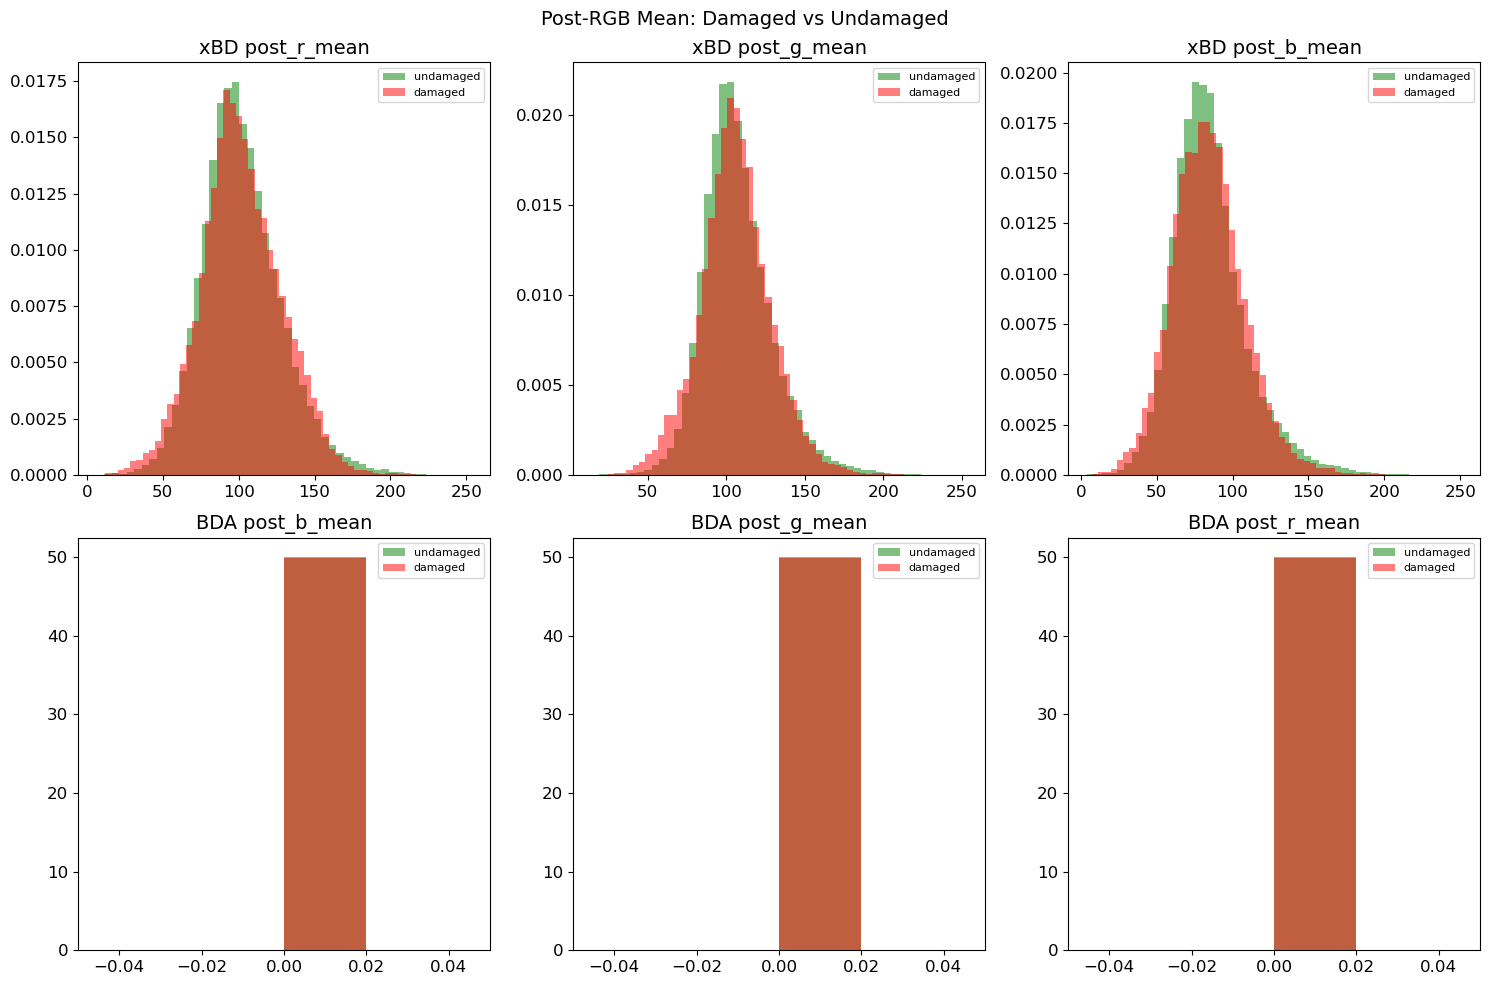

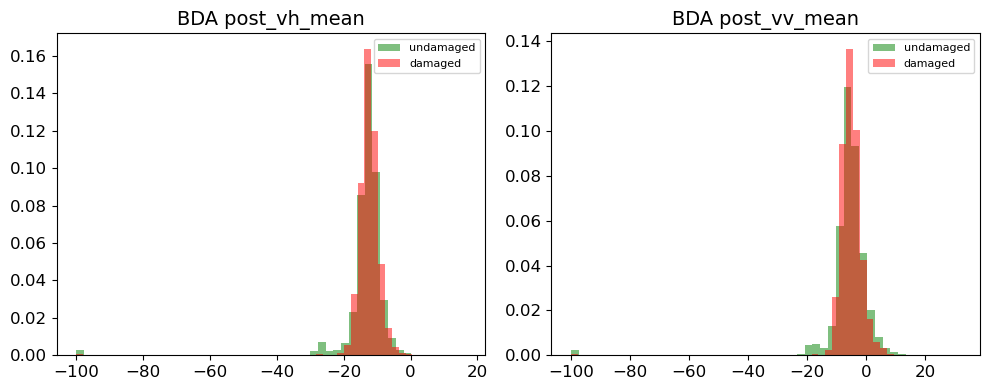


  Cohen's d (effect size) — damaged vs undamaged:
  Dataset   Feature                                     d
  xBD       delta_b_mean                            0.101
  xBD       delta_g_mean                           -0.012
  xBD       delta_r_mean                            0.151
  xBD       post_b_mean                            -0.032
  xBD       post_b_std                             -0.283
  xBD       post_g_mean                            -0.056
  xBD       post_g_std                             -0.268
  xBD       post_r_mean                            -0.008
  xBD       post_r_std                             -0.359
  xBD       pre_b_mean                             -0.103
  xBD       pre_b_std                              -0.146
  xBD       pre_g_mean                             -0.049
  xBD       pre_g_std                              -0.168
  xBD       pre_r_mean                             -0.122
  xBD       pre_r_std                              -0.188
  BDA       area_px  

In [8]:
# @title CELL 7: FEATURE DISTRIBUTIONS + COHEN'S D
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 7: FEATURE DISTRIBUTIONS")
print("=" * 70)

results_dir = RESULTS_ROOT / 'nb08b'
results_dir.mkdir(parents=True, exist_ok=True)

def cohens_d(g0, g1):
    n0, n1 = len(g0), len(g1)
    if n0 < 2 or n1 < 2:
        return np.nan
    var0, var1 = np.var(g0, ddof=1), np.var(g1, ddof=1)
    pooled = np.sqrt(((n0-1)*var0 + (n1-1)*var1) / (n0+n1-2))
    if pooled < 1e-10:
        return 0.0
    return (np.mean(g1) - np.mean(g0)) / pooled

# ---- RGB distributions ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Post-RGB Mean: Damaged vs Undamaged", fontsize=14)

if df_xbd is not None:
    for j, ch in enumerate(['post_r_mean', 'post_g_mean', 'post_b_mean']):
        if ch in df_xbd.columns:
            ax = axes[0, j]
            ax.hist(df_xbd.loc[df_xbd['damage_label']==0, ch].dropna(), bins=50,
                    alpha=0.5, label='undamaged', density=True, color='green')
            ax.hist(df_xbd.loc[df_xbd['damage_label']==1, ch].dropna(), bins=50,
                    alpha=0.5, label='damaged', density=True, color='red')
            ax.set_title(f"xBD {ch}")
            ax.legend(fontsize=8)

if df_bda is not None:
    bda_post_rgb = sorted([c for c in BDA_RGB if 'post' in c and 'mean' in c])[:3]
    for j, ch in enumerate(bda_post_rgb):
        ax = axes[1, j]
        vals = df_bda[ch].dropna()
        ax.hist(df_bda.loc[df_bda['damage_label']==0, ch].dropna(), bins=50,
                alpha=0.5, label='undamaged', density=True, color='green')
        ax.hist(df_bda.loc[df_bda['damage_label']==1, ch].dropna(), bins=50,
                alpha=0.5, label='damaged', density=True, color='red')
        ax.set_title(f"BDA {ch}")
        ax.legend(fontsize=8)
        if len(vals) > 0:
            lo, hi = np.percentile(vals, [1, 99])
            margin = (hi - lo) * 0.05
            ax.set_xlim(lo - margin, hi + margin)

plt.tight_layout()
plt.savefig(results_dir / 'rgb_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- CARD distributions ----
if df_bda is not None and len(BDA_CARD) > 0:
    card_post = sorted([c for c in BDA_CARD if 'post' in c and 'mean' in c])
    if card_post:
        fig2, axes2 = plt.subplots(1, len(card_post), figsize=(5*len(card_post), 4))
        if len(card_post) == 1:
            axes2 = [axes2]
        for j, ch in enumerate(card_post):
            ax = axes2[j]
            ax.hist(df_bda.loc[df_bda['damage_label']==0, ch].dropna(), bins=50,
                    alpha=0.5, label='undamaged', density=True, color='green')
            ax.hist(df_bda.loc[df_bda['damage_label']==1, ch].dropna(), bins=50,
                    alpha=0.5, label='damaged', density=True, color='red')
            ax.set_title(f"BDA {ch}")
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(results_dir / 'card_distributions.png', dpi=150, bbox_inches='tight')
        plt.show()

# ---- Cohen's d table ----
print("\n  Cohen's d (effect size) — damaged vs undamaged:")
print(f"  {'Dataset':8s}  {'Feature':35s}  {'d':>8s}")
all_effect_sizes = []

if df_xbd is not None:
    for ch in sorted(XBD_RGB):
        if ch == 'area_px':
            continue
        g0 = df_xbd.loc[df_xbd['damage_label']==0, ch].dropna().values
        g1 = df_xbd.loc[df_xbd['damage_label']==1, ch].dropna().values
        d = cohens_d(g0, g1)
        print(f"  {'xBD':8s}  {ch:35s}  {d:8.3f}")
        all_effect_sizes.append({'dataset': 'xBD', 'feature': ch, 'd': d})

if df_bda is not None:
    for ch in sorted(BDA_ALL):
        g0 = df_bda.loc[df_bda['damage_label']==0, ch].dropna().values
        g1 = df_bda.loc[df_bda['damage_label']==1, ch].dropna().values
        d = cohens_d(g0, g1)
        print(f"  {'BDA':8s}  {ch:35s}  {d:8.3f}")
        all_effect_sizes.append({'dataset': 'BDA', 'feature': ch, 'd': d})

if all_effect_sizes:
    df_es = pd.DataFrame(all_effect_sizes)
    df_es.to_csv(results_dir / 'effect_sizes.csv', index=False)

if df_coh_drop is not None and len(COH_DROP_FEAT) > 0:
    for ch in sorted(COH_DROP_FEAT):
        g0 = df_coh_drop.loc[df_coh_drop['damage_label']==0, ch].dropna().values
        g1 = df_coh_drop.loc[df_coh_drop['damage_label']==1, ch].dropna().values
        d = cohens_d(g0, g1)
        print(f"  {'COH_DROP':8s}  {ch:35s}  {d:8.3f}")
        all_effect_sizes.append({'dataset': 'COH_DROP', 'feature': ch, 'd': d})

    if all_effect_sizes:
        df_es = pd.DataFrame(all_effect_sizes)
        df_es.to_csv(results_dir / 'effect_sizes.csv', index=False)

print("\n  |d| > 0.2 small, > 0.5 medium, > 0.8 large")

# CELL 8: DIAGNOSTIC VERDICT

In [9]:
# @title CELL 8: DIAGNOSTIC VERDICT
print("=" * 70)
print("CELL 8: DIAGNOSTIC VERDICT")
print("=" * 70)

verdict_lines = [
    "",
    "INTERPRETATION GUIDE:",
    "",
    "1. xBD RGB AUC >> BDA RGB AUC (e.g. 0.85 vs 0.60):",
    "   -> ML pipeline works. BDA has weaker signal at 10m (expected).",
    "   -> SAR (CARD/COH) carries BDA signal, not MS RGB.",
    "   -> If BDA CARD AUC > BDA RGB AUC: confirms SAR is the modality.",
    "",
    "2. xBD RGB AUC ~ BDA RGB AUC (both > 0.70):",
    "   -> Both datasets have signal. BDA data stack is fine.",
    "   -> Previous poor results were from composites / wrong features.",
    "",
    "3. xBD RGB AUC < 0.65:",
    "   -> Building extraction broken. Debug NB01c.",
    "",
    "4. BDA CARD > BDA RGB:",
    "   -> SAR dominates at 10m. Focus on Dietrich RF pipeline (NB09a).",
    "   -> DL on RGB at 10m will always underperform.",
    "",
    "5. BDA RGB+CARD > BDA CARD alone:",
    "   -> MS adds value even at 10m. Multimodal fusion worth pursuing.",
]
for line in verdict_lines:
    print(line)


CELL 8: DIAGNOSTIC VERDICT

INTERPRETATION GUIDE:

1. xBD RGB AUC >> BDA RGB AUC (e.g. 0.85 vs 0.60):
   -> ML pipeline works. BDA has weaker signal at 10m (expected).
   -> SAR (CARD/COH) carries BDA signal, not MS RGB.
   -> If BDA CARD AUC > BDA RGB AUC: confirms SAR is the modality.

2. xBD RGB AUC ~ BDA RGB AUC (both > 0.70):
   -> Both datasets have signal. BDA data stack is fine.
   -> Previous poor results were from composites / wrong features.

3. xBD RGB AUC < 0.65:
   -> Building extraction broken. Debug NB01c.

4. BDA CARD > BDA RGB:
   -> SAR dominates at 10m. Focus on Dietrich RF pipeline (NB09a).
   -> DL on RGB at 10m will always underperform.

5. BDA RGB+CARD > BDA CARD alone:
   -> MS adds value even at 10m. Multimodal fusion worth pursuing.


In [10]:
# @title CELL 19: SAVE REGISTRY
import importlib
import bda_results
importlib.reload(bda_results)
registry.__class__ = bda_results.ResultRegistry
registry.save()

  SAVED: NB08b_experiments_20260424_062449.json (72 experiments)
  SAVED: NB08b_experiments_20260424_062449.csv


PosixPath('/content/drive_f/masterthesis/results/registry')